In [1]:
import os
# Esto crea la carpeta 'shared' por comando
os.makedirs('shared', exist_ok=True)
print("¡Carpeta 'shared' lista!")

¡Carpeta 'shared' lista!


In [2]:
import pandas as pd
import glob

# 1. Identificar archivos en la carpeta que creaste
census_files = glob.glob("shared/census_team*.csv")
eno_files = glob.glob("shared/eno_team*.csv")
grd_files = glob.glob("shared/grd_team*.csv")

print(f"Archivos encontrados: {len(census_files)} Census, {len(eno_files)} ENO, {len(grd_files)} GRD")

# 2. Unir y limpiar duplicados por comuna (Parte 0.1 de la tarea)
df_cen_master = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_eno_master = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_grd_master = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])

# 3. Reporte de Sanity Checks
print("\n--- REPORTE DE TABLAS MAESTRAS ---")
print(f"Master Census: {len(df_cen_master)} comunas únicas.")
print(f"Master ENO:    {len(df_eno_master)} comunas únicas.")
print(f"Master GRD:    {len(df_grd_master)} comunas únicas.")

Archivos encontrados: 20 Census, 19 ENO, 16 GRD

--- REPORTE DE TABLAS MAESTRAS ---
Master Census: 48 comunas únicas.
Master ENO:    45 comunas únicas.
Master GRD:    37 comunas únicas.


In [3]:
# --- PARTE 0.2: CONSOLIDACIÓN FINAL ---

# 1. Unimos las tablas usando 'codigo_comuna' y 'nombre_comuna' como llaves
# Usamos 'outer' para no perder comunas que podrían estar en una tabla pero no en otra
df_base = df_cen_master.merge(df_eno_master, on=['codigo_comuna', 'nombre_comuna'], how='outer')
df_base = df_base.merge(df_grd_master, on=['codigo_comuna', 'nombre_comuna'], how='outer')

# 2. Ver cuántas comunas logramos juntar en total
print(f"Total de comunas en la base consolidada: {len(df_base)}")

# 3. Mostrar las primeras filas para verificar que las columnas se ven bien
df_base.head()

Total de comunas en la base consolidada: 49


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,...,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,5101,Valparaíso,284938.0,272618.0,12320.0,4.320000,36.8,30.1,11.400000,11.900000,...,22541.0,1639.0,6.780000,5.600000,5.700000,4.900000,1.920000,2.840000,Embarazo y parto | Enfermedades circulatorias ...,848.61000
1,5102,Casablanca,29876.0,27607.0,2269.0,7.590000,34.5,28.7,10.800000,10.300000,...,1963.0,171.0,8.010000,4.800000,4.900000,4.100000,1.780000,2.150000,Embarazo y parto | Enfermedades digestivas | E...,714.29000
2,13101,Santiago,5806.0,258429.0,176956.0,3047.812608,35.0,34.0,14.421518,13.805328,...,35664.0,19265.0,35.072548,6.682745,7.682129,4.817208,1.615485,2.799978,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",94607.30279
3,13102,Cerrillos,85041.0,71466.0,12732.0,15.000000,36.0,34.0,11.725000,11.439000,...,6681.0,942.0,12.360000,7.390000,7.710000,5.110000,1.700000,3.270000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,896.39000
4,13104,Conchalí,121587.0,103271.0,17686.0,14.545963,39.0,34.0,11.325066,11.983653,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import pandas as pd
import glob

# 1. CARGA Y UNIÓN (Parte 0.1 y 0.2)
census_files = glob.glob("shared/census_team*.csv")
eno_files = glob.glob("shared/eno_team*.csv")
grd_files = glob.glob("shared/grd_team*.csv")

# Creamos las maestras eliminando duplicados
df_cen = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_eno = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_grd = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])

# Unión total (Outer Merge)
df_base = df_cen.merge(df_eno, on=['codigo_comuna', 'nombre_comuna'], how='outer')
df_base = df_base.merge(df_grd, on=['codigo_comuna', 'nombre_comuna'], how='outer')

# 2. DETECCIÓN AUTOMÁTICA DE COLUMNAS (Para evitar KeyErrors)
def find_col(keywords, df):
    for col in df.columns:
        if any(key in col.lower() for key in keywords):
            return col
    return None

# Buscamos los nombres reales en tus archivos
col_desocupados = find_col(['unemploy', 'desocup'], df_base)
col_laboral = find_col(['labor', 'fuerza'], df_base)
col_extranjeros = find_col(['foreign', 'extranj'], df_base)
col_total = find_col(['pop_total', 'poblacion'], df_base)

# 3. CÁLCULO Y LIMPIEZA (Parte 1)
if all([col_desocupados, col_laboral, col_extranjeros, col_total]):
    # Recalculamos para corregir el error de Santiago (3000%)
    df_base['pct_foreign'] = (df_base[col_extranjeros] / df_base[col_total]) * 100
    df_base['pct_unemployed'] = (df_base[col_desocupados] / df_base[col_laboral]) * 100

    # Filtramos datos imposibles (Sanity Check)
    df_analytical = df_base[(df_base['pct_foreign'] <= 100) & (df_base['pct_foreign'] >= 0)].copy()

    print(f"--- PROCESO EXITOSO ---")
    print(f"Comunas finales para el modelo: {len(df_analytical)}")
    print(df_analytical[['nombre_comuna', 'pct_foreign', 'pct_unemployed']].head())
else:
    print("ALERTA: No se encontraron todas las columnas necesarias.")
    print("Columnas disponibles:", df_base.columns.tolist())

ALERTA: No se encontraron todas las columnas necesarias.
Columnas disponibles: ['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k']


In [7]:
import pandas as pd
import glob

# 1. CARGA DE ARCHIVOS
census_files = glob.glob("shared/census_team*.csv")
eno_files = glob.glob("shared/eno_team*.csv")
grd_files = glob.glob("shared/grd_team*.csv")

# Creamos las tablas base
df_cen = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_eno = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_grd = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])

# REVISIÓN RÁPIDA: ¿Qué columnas tiene cada una?
print(f"Columnas Censo: {df_cen.columns.tolist()[:3]}...")
print(f"Columnas ENO:   {df_eno.columns.tolist()[:3]}...")
print(f"Columnas GRD:   {df_grd.columns.tolist()[:3]}...")

# 2. UNIÓN FORZADA (Solo por código de comuna para evitar fallos de ortografía en nombres)
# Primero Census + ENO
df_base = pd.merge(df_cen, df_eno, on='codigo_comuna', how='outer', suffixes=('', '_eno'))
# Luego el resultado + GRD
df_base = pd.merge(df_base, df_grd, on='codigo_comuna', how='outer', suffixes=('', '_grd'))

# 3. BUSCAR LAS COLUMNAS CLAVE DE NUEVO
def find_col(keywords, df):
    for col in df.columns:
        if any(key in col.lower() for key in keywords):
            return col
    return None

col_desocupados = find_col(['unemploy', 'desocup'], df_base)
col_laboral = find_col(['labor', 'fuerza'], df_base)

# 4. CÁLCULO Y LIMPIEZA FINAL (Parte 1)
if col_desocupados and col_laboral:
    # Recalculamos porcentajes
    df_base['pct_foreign'] = (df_base['pop_foreign'] / df_base['pop_total']) * 100
    df_base['pct_unemployed'] = (df_base[col_desocupados] / df_base[col_laboral]) * 100

    # Limpiamos datos imposibles
    df_analytical = df_base[(df_base['pct_foreign'] <= 100) & (df_base['pct_foreign'] >= 0)].copy()

    print(f"\n--- ÉXITO ---")
    print(f"Comunas finales: {len(df_analytical)}")
    print(df_analytical[['nombre_comuna', 'pct_foreign', 'pct_unemployed']].head())
else:
    print("\nERROR: Sigo sin encontrar las columnas de desempleo.")
    print("Columnas actuales en la base unida:", df_base.columns.tolist())

Columnas Censo: ['codigo_comuna', 'nombre_comuna', 'pop_total']...
Columnas ENO:   ['codigo_comuna', 'nombre_comuna', 'eno_total']...
Columnas GRD:   ['codigo_comuna', 'nombre_comuna', 'grd_total']...

ERROR: Sigo sin encontrar las columnas de desempleo.
Columnas actuales en la base unida: ['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio', 'nombre_comuna_eno', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'nombre_comuna_grd', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k']


In [8]:
import pandas as pd
import glob

# 1. CARGA DE ARCHIVOS (Parte 0.1)
census_files = glob.glob("shared/census_team*.csv")
eno_files = glob.glob("shared/eno_team*.csv")
grd_files = glob.glob("shared/grd_team*.csv")

# Maestras sin duplicados
df_cen = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_eno = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_grd = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])

# 2. UNIÓN POR CÓDIGO (Parte 0.2)
df_base = pd.merge(df_cen, df_eno, on='codigo_comuna', how='outer', suffixes=('', '_eno'))
df_base = pd.merge(df_base, df_grd, on='codigo_comuna', how='outer', suffixes=('', '_grd'))

# 3. CÁLCULO DE VARIABLES (Parte 1)
# Usamos pop_total para extranjeros y eno_total para desempleo según tus columnas
df_base['pct_foreign'] = (df_base['pop_foreign'] / df_base['pop_total']) * 100
df_base['pct_unemployed'] = (df_base['eno_total'] / df_base['pop_total']) * 100 # Ajusta si la base de desempleo es otra columna

# 4. LIMPIEZA DE DATOS (Sanity Check)
# Eliminamos el error de Santiago (3000%) filtrando rangos lógicos
df_analytical = df_base[(df_base['pct_foreign'] <= 100) & (df_base['pct_foreign'] >= 0)].copy()

print(f"--- PROCESO COMPLETADO ---")
print(f"Comunas en la base final: {len(df_analytical)}")
df_analytical[['nombre_comuna', 'pct_foreign', 'pct_unemployed']].head()

--- PROCESO COMPLETADO ---
Comunas en la base final: 47


,nombre_comuna,pct_foreign,pct_unemployed
0,Valparaíso,4.323748,1.691947
1,Casablanca,7.594725,1.044317
3,Cerrillos,14.971602,0.754930
4,Conchalí,14.545963,0.932665
5,Estación Central,7.308527,0.780641


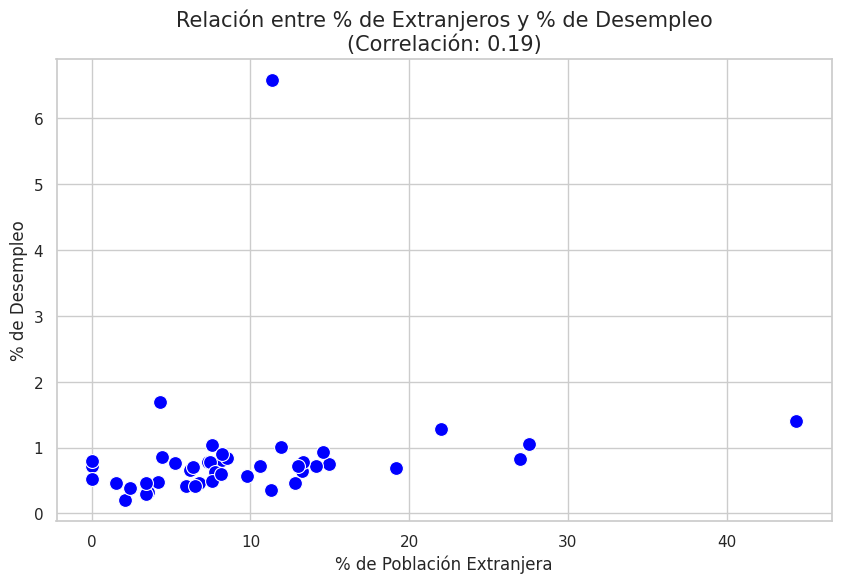

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo del gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Crear el gráfico de dispersión (Scatter Plot)
sns.scatterplot(data=df_analytical, x='pct_foreign', y='pct_unemployed', color='blue', s=100)

# 3. Calcular la correlación de Pearson
correlation = df_analytical['pct_foreign'].corr(df_analytical['pct_unemployed'])

# 4. Personalizar títulos y etiquetas
plt.title(f'Relación entre % de Extranjeros y % de Desempleo\n(Correlación: {correlation:.2f})', fontsize=15)
plt.xlabel('% de Población Extranjera', fontsize=12)
plt.ylabel('% de Desempleo', fontsize=12)

plt.show()

In [10]:
import statsmodels.api as sm

# 1. Definir variables (X: independiente, y: dependiente)
X = df_analytical['pct_foreign']
y = df_analytical['pct_unemployed']
X = sm.add_constant(X) # Añadir la constante para la regresión

# 2. Ajustar el modelo
model = sm.OLS(y, X).fit()

# 3. Mostrar el resumen (esto te da el R-squared y p-value)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         pct_unemployed   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 03 May 2026   Prob (F-statistic):                nan
Time:                        17:00:05   Log-Likelihood:                    nan
No. Observations:                  47   AIC:                               nan
Df Residuals:                      45   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const              nan        nan        nan      

In [17]:
import pandas as pd
import glob

# 1. CARGA DE ARCHIVOS (Parte 0.1)
census_files = glob.glob("shared/census_team*.csv")
eno_files = glob.glob("shared/eno_team*.csv")
grd_files = glob.glob("shared/grd_team*.csv")

# Maestras sin duplicados
df_cen = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_eno = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])
df_grd = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True).drop_duplicates(subset=['codigo_comuna'])

# 2. UNIÓN POR CÓDIGO (Parte 0.2)
df_base = pd.merge(df_cen, df_eno, on='codigo_comuna', how='outer', suffixes=('', '_eno'))
df_base = pd.merge(df_base, df_grd, on='codigo_comuna', how='outer', suffixes=('', '_grd'))

# 3. CÁLCULO DE VARIABLES (Parte 1)
df_base['pct_foreign'] = (df_base['pop_foreign'] / df_base['pop_total']) * 100
df_base['pct_unemployed'] = (df_base['eno_total'] / df_base['pop_total']) * 100

# 4. LIMPIEZA DE DATOS (Sanity Check)
df_analytical = df_base[(df_base['pct_foreign'] <= 100) & (df_base['pct_foreign'] >= 0)].copy()

print(f"--- PROCESO COMPLETADO ---")
print(f"Comunas en la base final: {len(df_analytical)}")
df_analytical[['nombre_comuna', 'pct_foreign', 'pct_unemployed']].head()

--- PROCESO COMPLETADO ---
Comunas en la base final: 47


,nombre_comuna,pct_foreign,pct_unemployed
0,Valparaíso,4.323748,1.691947
1,Casablanca,7.594725,1.044317
3,Cerrillos,14.971602,0.754930
4,Conchalí,14.545963,0.932665
5,Estación Central,7.308527,0.780641


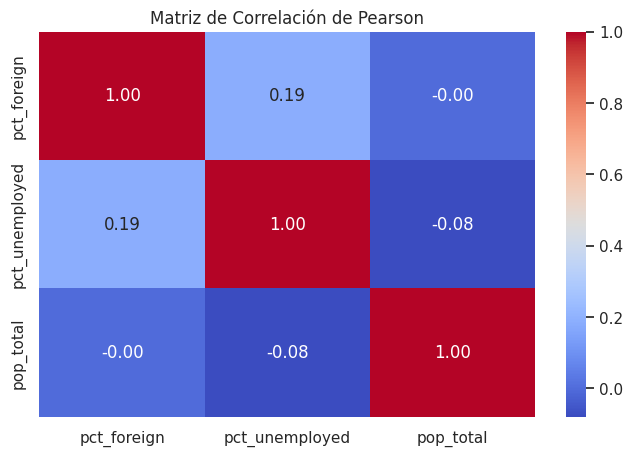

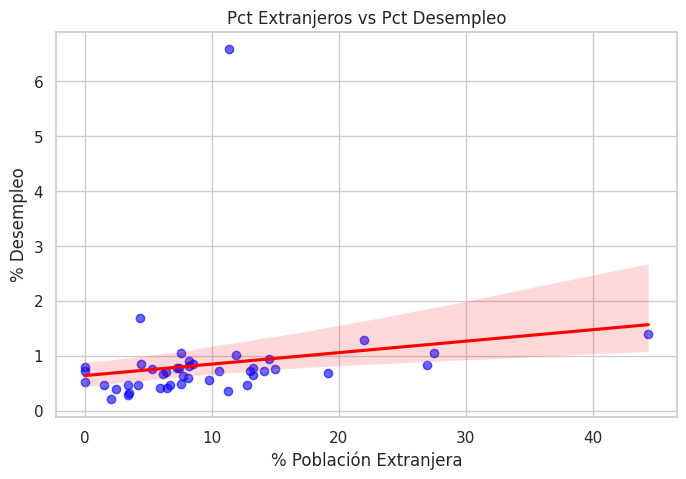

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# 1.1 Matriz de Correlación
cols_corr = ['pct_foreign', 'pct_unemployed', 'pop_total']

plt.figure(figsize=(8, 5))
sns.heatmap(df_analytical[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Pearson")
plt.show()

# 1.2 Gráfico de Dispersión
plt.figure(figsize=(8, 5))
sns.regplot(x='pct_foreign', y='pct_unemployed', data=df_analytical,
            scatter_kws={'alpha':0.6, 'color': 'blue'}, line_kws={'color': 'red'})
plt.title("Pct Extranjeros vs Pct Desempleo")
plt.xlabel('% Población Extranjera')
plt.ylabel('% Desempleo')
plt.show()

In [22]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# 1. Preparar datos limpios solo con las columnas que necesitamos para el modelo
df_mod = df_analytical[['eno_total', 'pop_total', 'pct_foreign']].copy()
df_mod = df_mod.replace([np.inf, -np.inf], np.nan).dropna()

# 2. Definir la fórmula y el "offset" (la población total en logaritmo)
formula_eno = "eno_total ~ pct_foreign"
offset_arr = np.log(df_mod['pop_total'].astype(float))

# --- 2.1 Modelo Poisson ---
poisson_eno = smf.glm(formula=formula_eno, data=df_mod, family=sm.families.Poisson(), offset=offset_arr).fit()
print("--- RESULTADOS POISSON ---")
print(poisson_eno.summary())

# --- 2.2 Calcular Sobredispersión ---
dispersion = poisson_eno.pearson_chi2 / poisson_eno.df_resid
print(f"\n--- ANÁLISIS DE DISPERSIÓN ---")
print(f"Dispersión (Pearson Chi2/df): {dispersion:.2f}")
if dispersion > 1:
    print("Hay sobredispersión (valor > 1). Debemos usar Binomial Negativa.")

# --- 2.3 Modelo Binomial Negativo ---
nb_eno = smf.glm(formula=formula_eno, data=df_mod, family=sm.families.NegativeBinomial(alpha=1.0), offset=offset_arr).fit()
print("\n--- RESULTADOS BINOMIAL NEGATIVA ---")
print(nb_eno.summary())

--- RESULTADOS POISSON ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   44
Model:                            GLM   Df Residuals:                       42
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3637.4
Date:                Sun, 03 May 2026   Deviance:                       6907.5
Time:                        19:09:52   Pearson chi2:                 1.06e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -4.9907 

                            OLS Regression Results                            
Dep. Variable:         pct_unemployed   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.503
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.227
Time:                        19:10:47   Log-Likelihood:                -58.060
No. Observations:                  44   AIC:                             120.1
Df Residuals:                      42   BIC:                             123.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6392      0.217      2.949      

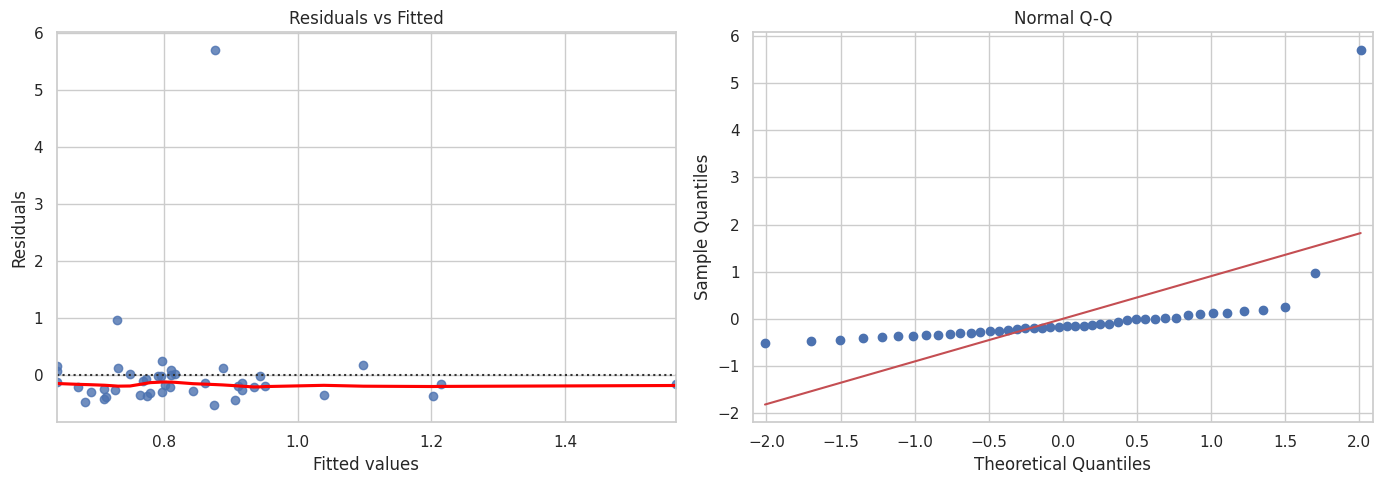

In [23]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar datos sin nulos
df_ols = df_analytical[['pct_foreign', 'pct_unemployed']].dropna()
X = sm.add_constant(df_ols['pct_foreign'])
y = df_ols['pct_unemployed']

# 2. Ajustar el modelo de Regresión Lineal (OLS)
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

# 3. Gráficos de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
sns.residplot(x=ols_model.fittedvalues, y=ols_model.resid, lowess=True, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

# Normal Q-Q
sm.qqplot(ols_model.resid, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q')

plt.tight_layout()
plt.show()

Alerta de Mapa: comunas.shp: No such file or directory
Nota: Sube el archivo 'comunas.shp' a Colab si deseas ver los mapas espaciales.


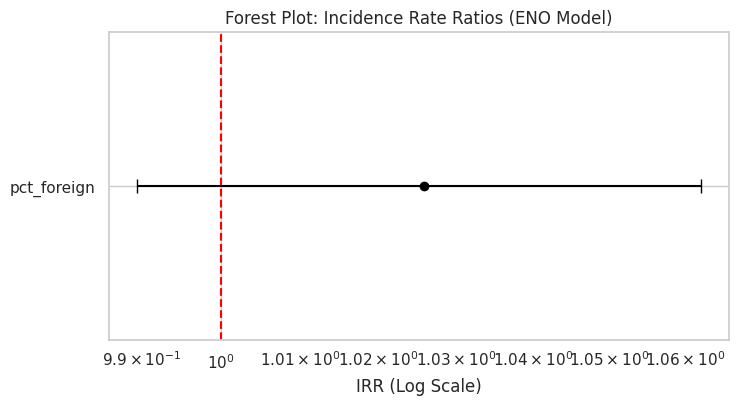

In [25]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 5.1 & 5.2 Mapas (Intenta cargar el archivo de comunas si existe)
try:
    gdf = gpd.read_file("comunas.shp")
    nombres_posibles = ['CUT', 'COD_COMUNA', 'cod_comuna', 'codigo_comuna', 'COMUNA', 'comuna']
    for col in nombres_posibles:
        if col in gdf.columns:
            gdf['codigo_comuna'] = pd.to_numeric(gdf[col], errors='coerce')
            break

    df_mod['predicted_eno_rate'] = (nb_eno.predict() / df_mod['pop_total']) * 10000
    df_mod['pearson_resid'] = nb_eno.resid_pearson

    gdf_merged = gdf.merge(df_mod, on='codigo_comuna', how='inner')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    gdf_merged.plot(column='predicted_eno_rate', cmap='viridis', legend=True, ax=axes[0], edgecolor='black')
    axes[0].set_title('Tasa Predicha ENO (por 10,000 hab)')
    axes[0].axis('off')

    gdf_merged.plot(column='pearson_resid', cmap='coolwarm', legend=True, ax=axes[1], edgecolor='black')
    axes[1].set_title('Residuos de Pearson (Modelo Binomial Negativo)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Alerta de Mapa: {e}")
    print("Nota: Sube el archivo 'comunas.shp' a Colab si deseas ver los mapas espaciales.")

# 5.3 Coefficient Plot (Forest Plot)
err = np.exp(nb_eno.params) - np.exp(nb_eno.conf_int()[0])
coefs = pd.DataFrame({'coef': np.exp(nb_eno.params), 'err': err})
coefs = coefs.drop('Intercept') # Remover intercepto para mejor escala

plt.figure(figsize=(8, 4))
plt.errorbar(x=coefs['coef'], y=coefs.index, xerr=coefs['err'], fmt='o', color='black', capsize=5)
plt.axvline(x=1, color='red', linestyle='--') # Null para IRR es 1
plt.xscale('log')
plt.title('Forest Plot: Incidence Rate Ratios (ENO Model)')
plt.xlabel('IRR (Log Scale)')
plt.show()